In [1]:
!git clone https://github.com/TrustworthyMachineLearning-Lab/grokking_flatness.git
%cd grokking_flatness

Cloning into 'grokking_flatness'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 90 (delta 18), reused 74 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 1.06 MiB | 21.68 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/grokking_flatness


In [6]:
import os

LEARNING_RATE = "1e-02"
SEED = 15213
TRAINING_EPOCH = 150
CANCEL_EPOCH = 10000
CANCEL_DUR_EPOCH = 10
BSZ = 256
WEIGHTDECAY = 0
USE_REGR = 1
USE_POW = 1
HECOEFF = "1e-3"
CLIPPING_VALUE = 0
OPTM = "sgd"
TRAINING_SIZE = 0.0

from datetime import datetime
DATE = datetime.now().strftime("%m%d")

# Pre-compute the output dir name so we can load files later
OUTPUT_DIR = (
    f"Seed{SEED}_Date{DATE}_TSIZE{TRAINING_SIZE}_BSZ{BSZ}_OPTM{OPTM}"
    f"_LR{LEARNING_RATE}_EPOCH{TRAINING_EPOCH}_CANECH{CANCEL_EPOCH}"
    f"_CANECHDUR{CANCEL_DUR_EPOCH}_WD{WEIGHTDECAY}_REGR{USE_REGR}"
    f"_LIPZ{USE_POW}_LAMBDA{HECOEFF}_GCP{float(CLIPPING_VALUE)}"
)
print("Output will be saved to:", OUTPUT_DIR)

Output will be saved to: Seed15213_Date0309_TSIZE0.0_BSZ256_OPTMsgd_LR1e-02_EPOCH150_CANECH10000_CANECHDUR10_WD0_REGR1_LIPZ1_LAMBDA1e-3_GCP0.0


In [7]:
%cd /content/grokking_flatness/nc_experiments

/content/grokking_flatness/nc_experiments


In [8]:
!python train.py \
    --learning_rate={LEARNING_RATE} \
    --training_date={DATE} \
    --random_seed={SEED} \
    --epochs={TRAINING_EPOCH} \
    --cancel_epoch={CANCEL_EPOCH} \
    --cancel_dur_epoch={CANCEL_DUR_EPOCH} \
    --batch_size={BSZ} \
    --weight_decay={WEIGHTDECAY} \
    --use_regulation={USE_REGR} \
    --use_pow={USE_POW} \
    --lambda={HECOEFF} \
    --clip_value={CLIPPING_VALUE} \
    --optim_type={OPTM} \
    --training_size={TRAINING_SIZE}

[INFO]: Training ResNet18 built from scratch...
11,181,642 total parameters.
11,181,642 training parameters.
model: scratch
learning_rate: 0.01
training_date: 0309
random_seed: 15213
epochs: 150
cancel_epoch: 10000
cancel_dur_epoch: 10
batch_size: 256
weight_decay: 0.0
use_regulation: 1
lambda: 0.001
clip_value: 0.0
optim_type: sgd
training_size: 0.0
use_pow: 1
[INFO]: Epoch 1 of 150
Training
/content/grokking_flatness/nc_experiments/training_utils.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  var_class_cluster_list.append(torch.tensor([c1, var1, c2, var2, temp_result]))
Validation
Training loss: 1.428, training acc: 48.546
Validation loss: 1.154, validation acc: 59.140
--------------------------------------------------
2026-03-09 00:20:41.431726
[INFO]: Epoch 2 of 150
Training
Validation

In [13]:
import os

# Find the output dir created during training
# candidates = [d for d in os.listdir('.') if d.startswith(f"Seed{SEED}")]
# assert len(candidates) > 0, "No output dir found — did training finish?"
OUTPUT_DIR = '/content/grokking_flatness/nc_experiments/Seed15213_Date0309_TSIZE0.0_BSZ256_OPTMsgd_LR0.01_EPOCH150_CANECH10000_CANECHDUR10_WD0.0_REGR1_LIPZ1_LAMBDA0.001_GCP0.0'
print("Output dir:", OUTPUT_DIR)

os.chdir(OUTPUT_DIR)
print("Now in:", os.getcwd())

Output dir: /content/grokking_flatness/nc_experiments/Seed15213_Date0309_TSIZE0.0_BSZ256_OPTMsgd_LR0.01_EPOCH150_CANECH10000_CANECHDUR10_WD0.0_REGR1_LIPZ1_LAMBDA0.001_GCP0.0
Now in: /content/grokking_flatness/nc_experiments/Seed15213_Date0309_TSIZE0.0_BSZ256_OPTMsgd_LR0.01_EPOCH150_CANECH10000_CANECHDUR10_WD0.0_REGR1_LIPZ1_LAMBDA0.001_GCP0.0


Found: 150 sharpness, 150 train_acc, 150 val_acc files


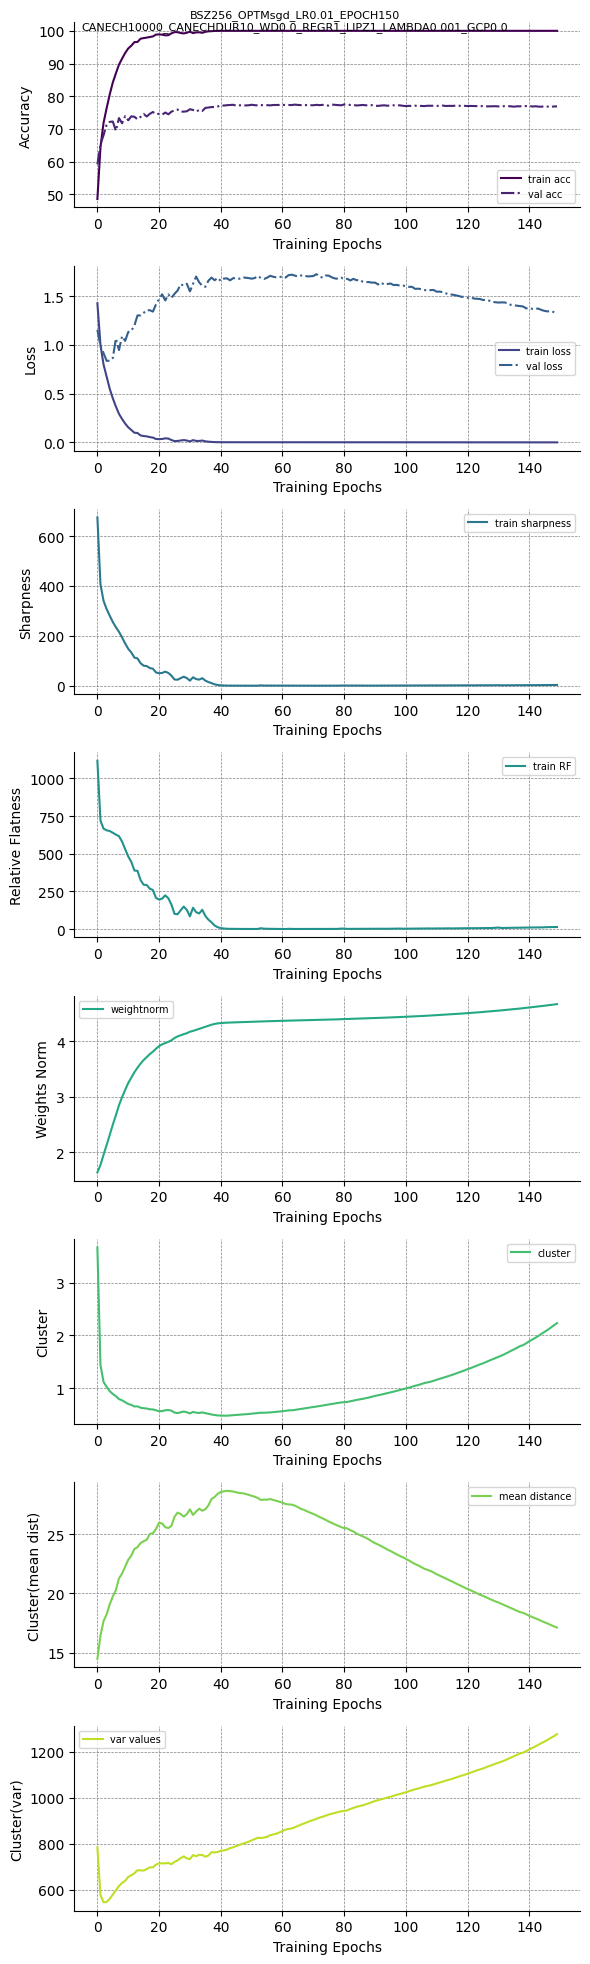

Saved!


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os
import collections

dir_name = "."
dirs = os.listdir(".")

# ---- load filenames ----
file_name_sharpness, file_name_sharpness2 = [], []
file_name_train_loss, file_name_train_acc = [], []
file_name_val_loss, file_name_val_acc = [], []
file_name_weights_norm, file_name_cluster_value = [], []
file_name_mean_value, file_name_var_classcluster = [], []

for item in dirs:
    if   "sharpness2_"    in item: file_name_sharpness2.append(item)
    elif "sharpness_"     in item: file_name_sharpness.append(item)
    elif "train_acc_"     in item: file_name_train_acc.append(item)
    elif "val_acc_"       in item: file_name_val_acc.append(item)
    elif "train_loss_"    in item: file_name_train_loss.append(item)
    elif "val_loss_"      in item: file_name_val_loss.append(item)
    elif "weights_norm_"  in item: file_name_weights_norm.append(item)
    elif "cluster_value"  in item: file_name_cluster_value.append(item)
    elif "mean_value"     in item: file_name_mean_value.append(item)
    elif "var_classcluster" in item: file_name_var_classcluster.append(item)

print(f"Found: {len(file_name_sharpness)} sharpness, {len(file_name_train_acc)} train_acc, {len(file_name_val_acc)} val_acc files")

# ---- helper to load ordered arrays ----
def load_ordered(file_list):
    d = {}
    for item in file_list:
        key = int(item.split("_")[-1].split(".")[0])
        d[key] = item
    d = collections.OrderedDict(sorted(d.items()))
    steps, arrays = [], []
    for key, value in d.items():
        steps.append(key)
        arrays.append(np.load(os.path.join(dir_name, value)))
    return steps, np.array(arrays)

sharpness_step_list,      sharpness_array      = load_ordered(file_name_sharpness)
sharpness2_step_list,     sharpness2_array     = load_ordered(file_name_sharpness2)
train_loss_step_list,     train_loss_array     = load_ordered(file_name_train_loss)
val_loss_step_list,       val_loss_array       = load_ordered(file_name_val_loss)
train_acc_step_list,      train_acc_array      = load_ordered(file_name_train_acc)
val_acc_step_list,        val_acc_array        = load_ordered(file_name_val_acc)
train_cluster_step_list,  train_cluster_array  = load_ordered(file_name_cluster_value)
weightnorm_step_list,     weightnorm_array     = load_ordered(file_name_weights_norm)

# mean_value and var_classcluster need custom aggregation (as per authors)
mean_value_dict = {}
for item in file_name_mean_value:
    key = int(item.split("_")[-1].split(".")[0])
    mean_value_dict[key] = item
mean_value_dict = collections.OrderedDict(sorted(mean_value_dict.items()))
mean_value_step_list, mean_value_array = [], []
for key, value in mean_value_dict.items():
    temp_data = np.load(os.path.join(dir_name, value))
    mean_value_step_list.append(key)
    mean_value_array.append(np.mean(np.linalg.norm((temp_data[:,0] - temp_data[:,1]), axis=1)))
mean_value_array = np.array(mean_value_array)

var_classcluster_dict = {}
for item in file_name_var_classcluster:
    key = int(item.split("_")[-1].split(".")[0])
    var_classcluster_dict[key] = item
var_classcluster_dict = collections.OrderedDict(sorted(var_classcluster_dict.items()))
var_classcluster_step_list, var_classcluster_array = [], []
for key, value in var_classcluster_dict.items():
    temp_data = np.load(os.path.join(dir_name, value))
    var_classcluster_step_list.append(key)
    var_classcluster_array.append(np.mean(temp_data[:, 1] + temp_data[:, 3]))
var_classcluster_array = np.array(var_classcluster_array)

# ---- plot (authors' exact style) ----
t = os.getcwd().split("/")[-1].split("TSIZE0.0_")[-1].split("_")
t1 = "_".join(t[:4])
t2 = "_".join(t[4:])

fig, ax = plt.subplots(8, 1, figsize=(6, 20))
fig.suptitle("{}\n{}".format(t1, t2), fontsize=8)

cmap = plt.get_cmap('viridis')
colors = [cmap(p) for p in np.linspace(0, 0.9, 10)]

ax[0].plot(train_acc_step_list,      train_acc_array,      color=colors[0], label="train acc")
ax[0].plot(val_acc_step_list,        val_acc_array,        color=colors[1], label="val acc", linestyle='-.')
ax[1].plot(train_loss_step_list,     train_loss_array,     color=colors[2], label="train loss")
ax[1].plot(val_loss_step_list,       val_loss_array,       color=colors[3], label="val loss", linestyle='-.')
ax[2].plot(sharpness_step_list,      sharpness_array,      color=colors[4], label="train sharpness")
ax[3].plot(sharpness2_step_list,     sharpness2_array,     color=colors[5], label="train RF")
ax[4].plot(weightnorm_step_list,     weightnorm_array,     color=colors[6], label="weightnorm")
ax[5].plot(train_cluster_step_list,  train_cluster_array,  color=colors[7], label="cluster")
ax[6].plot(mean_value_step_list,     mean_value_array,     color=colors[8], label="mean distance")
ax[7].plot(var_classcluster_step_list, var_classcluster_array, color=colors[9], label="var values")

ylabels = ["Accuracy","Loss","Sharpness","Relative Flatness","Weights Norm","Cluster","Cluster(mean dist)","Cluster(var)"]
for i, (a, ylabel) in enumerate(zip(ax, ylabels)):
    a.set_xlabel("Training Epochs")
    a.set_ylabel(ylabel)
    a.legend(fontsize=7)
    a.spines[['right','top']].set_visible(False)
    a.grid(True, linestyle='--', linewidth=0.5, color='gray')

fig.tight_layout()
plt.savefig('figure2_replicated.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure2_replicated.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")